In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [2]:
using_colab = False

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/home/user/Projects/sam3/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/user/miniconda3/envs/sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [5]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# Build Model

In [6]:
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

In [7]:
# image_path = f"{sam3_root}/assets/images/hose.jpg"

image_path = f"{sam3_root}/assets/images/extracted_images/images/frame_000014_1767881926.575840.png"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

# Text prompt

In [8]:
processor.reset_all_prompts(inference_state)

In [ ]:
from sam3.visualization_utils import plot_mask, plot_bbox, COLORS

def plot_data(img, scores, masks, color_id):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)

    nb_objects = len(scores)
    print(f"found {nb_objects} object(s)")

    for i in range(nb_objects):
        color = COLORS[color_id % len(COLORS)]

        plot_mask(
            masks[i].squeeze(0).cpu(),
            color=color
        )


found 2 object(s)


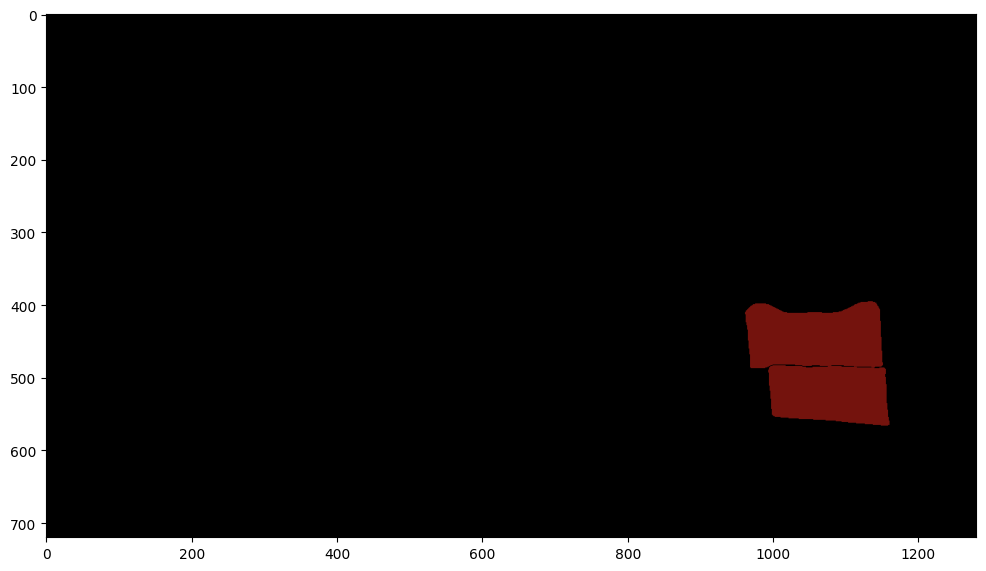

In [10]:
scores = []
masks = []
boxes = []

inference_state = processor.set_text_prompt(state=inference_state, prompt="crate")

scores.extend(inference_state["scores"])
masks.extend(inference_state["masks"])
boxes.extend(inference_state["boxes"])

img0 = Image.open(image_path)

empty_img = Image.new(img0.mode, img0.size)

plot_data(empty_img, scores, masks, 0)

In [ ]:
import json
import os
import time

input_dir = f"{sam3_root}/assets/images/folder_processing/input"
output_dir = f"{sam3_root}/assets/images/folder_processing/output"

os.makedirs(output_dir, exist_ok=True)

def get_json_name(image_name):
    return f"out_{image_name.replace('.png', '.json')}"

while True:
    # --- Iterate over images ---
    for img_name in sorted(os.listdir(input_dir)):
        if not img_name.endswith(".png"):
            continue

        img_path = os.path.join(input_dir, img_name)
        json_path = os.path.join(input_dir, get_json_name(img_name))

        if not os.path.exists(json_path):
            print(f"Missing JSON for {img_name}")
            continue

        # --- Load image ---
        image = Image.open(img_path)

        # --- Load labels ---
        with open(json_path, "r") as f:
            data = json.load(f)

        labels = data.get("labels", [])

        # --- Reset state once per image ---
        inference_state = processor.set_image(image)
        processor.reset_all_prompts(inference_state)

        empty_img = Image.new(img0.mode, img0.size)
        plt.figure(figsize=(12, 8))
        plt.imshow(empty_img)

        # --- Apply each label ---
        found_labels = []
        
        for label in labels:
            inference_state = processor.set_text_prompt(
                state=inference_state,
                prompt=label
            )
            scores = inference_state["scores"]
            masks = inference_state["masks"]

            nb_objects = len(scores)
            print(f"found {nb_objects} object(s)")

            if label in found_labels:
                color_idx = found_labels.index(label)
            else:
                found_labels.append(label)
                color_idx = len(found_labels) - 1

            for i in range(nb_objects):
                color = COLORS[color_idx % len(COLORS)]

                plot_mask(
                    masks[i].squeeze(0).cpu(),
                    color=color
                )

        # --- Save output ---
        out_path = os.path.join(output_dir, f"{img_name}")
        plt.savefig(out_path, bbox_inches="tight")
        plt.close()

        data = {
            "labels": found_labels
        }
        out_json_path = os.path.join(output_dir, f"{get_json_name(img_name)}")
        with open(out_json_path, "w") as f:
            json.dump(data, f, indent=2)

        print(f"Saved: {out_path}")

        os.remove(img_path)
        os.remove(json_path)
    time.sleep(1)

found 2 object(s)
found 2 object(s)
found 0 object(s)
found 4 object(s)
found 5 object(s)
Saved: /home/user/Projects/sam3/sam3/sam3/../assets/images/folder_processing/output/frame_000000_1767881912.638185.png
